Numerical:  5.99999999
Analytical: 6.00000000
Error:      9.82e-09
d/dx[sin(x)] at 0.785:  numerical=0.707107, analytical=0.707107
d/dx[e^x] at 1.000:  numerical=2.718282, analytical=2.718282


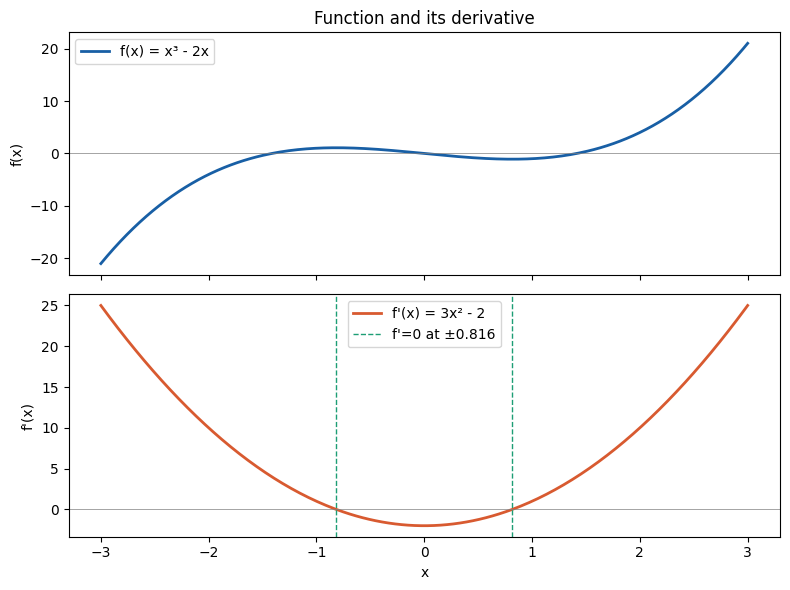

GD converged to w=2.499899 (true min=2.5)


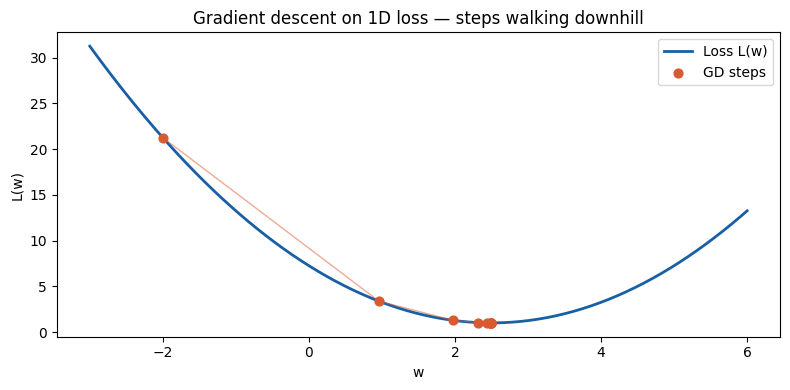

2D GD converged to [ 1.1611 -0.6451] (true min near [0.9, -0.6])


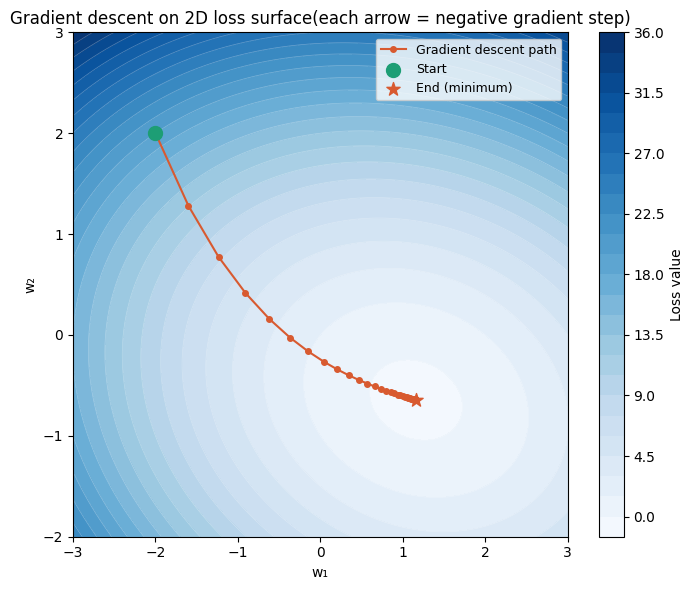

Save as day07_derivatives.ipynb and push to GitHub.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Numerical derivative — limit definition in code ───
def numerical_derivative(f, x, h=1e-7):
    return (f(x + h) - f(x - h)) / (2 * h)  # central difference

f  = lambda x: x**2
df = lambda x: 2*x   # analytical

x_test = 3.0
numerical = numerical_derivative(f, x_test)
analytical = df(x_test)
print(f"Numerical:  {numerical:.8f}")   # 6.00000000
print(f"Analytical: {analytical:.8f}")  # 6.00000000
print(f"Error:      {abs(numerical-analytical):.2e}")  # ~1e-14

# Test with more functions
g   = lambda x: np.sin(x)
dg  = lambda x: np.cos(x)
h_fn = lambda x: np.exp(x)
dh  = lambda x: np.exp(x)   # e^x is its own derivative

for fn, dfn, name, pt in [(g,dg,'sin(x)',np.pi/4),(h_fn,dh,'e^x',1.0)]:
    num = numerical_derivative(fn, pt)
    ana = dfn(pt)
    print(f"d/dx[{name}] at {pt:.3f}:  numerical={num:.6f}, analytical={ana:.6f}")

# ── 2. Plot a function and its derivative ─────────────────
x = np.linspace(-3, 3, 300)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

ax1.plot(x, x**3 - 2*x, color='#185FA5', lw=2, label='f(x) = x³ - 2x')
ax1.axhline(0, color='gray', lw=0.5)
ax1.set_ylabel('f(x)'); ax1.legend(); ax1.set_title("Function and its derivative")

ax2.plot(x, 3*x**2 - 2, color='#D85A30', lw=2, label="f'(x) = 3x² - 2")
ax2.axhline(0, color='gray', lw=0.5)
# Mark where f'(x)=0 (critical points)
critical = np.sqrt(2/3)
ax2.axvline( critical, color='#1D9E75', lw=1, ls='--', label=f"f'=0 at ±{critical:.3f}")
ax2.axvline(-critical, color='#1D9E75', lw=1, ls='--')
ax2.set_ylabel("f'(x)"); ax2.set_xlabel('x'); ax2.legend()

plt.tight_layout(); plt.show()

# ── 3. Gradient descent on 1D loss ───────────────────────
def loss_1d(w):      return (w - 2.5)**2 + 1
def grad_1d(w):      return 2*(w - 2.5)

w = -2.0      # start far from minimum
lr = 0.15
history = [w]

for step in range(30):
    g = grad_1d(w)
    w = w - lr * g
    history.append(w)

print(f"GD converged to w={w:.6f} (true min=2.5)")

w_range = np.linspace(-3, 6, 300)
plt.figure(figsize=(8, 4))
plt.plot(w_range, loss_1d(w_range), color='#185FA5', lw=2, label='Loss L(w)')
plt.scatter(history[::3], [loss_1d(h) for h in history[::3]],
            color='#D85A30', s=40, zorder=5, label='GD steps')
plt.plot(history[::3], [loss_1d(h) for h in history[::3]],
         color='#D85A30', lw=1, alpha=0.5)
plt.xlabel('w'); plt.ylabel('L(w)')
plt.title('Gradient descent on 1D loss — steps walking downhill')
plt.legend(); plt.tight_layout(); plt.show()

# ── 4. Gradient descent on 2D loss — the money shot ──────
def loss_2d(w1, w2):
    return (w1 - 1)**2 + 2*(w2 + 0.5)**2 + 0.5*w1*w2

def grad_2d(w1, w2):
    dl_dw1 = 2*(w1 - 1) + 0.5*w2
    dl_dw2 = 4*(w2 + 0.5) + 0.5*w1
    return np.array([dl_dw1, dl_dw2])

# Run gradient descent
w = np.array([-2.0, 2.0])
lr = 0.08
path = [w.copy()]
for _ in range(60):
    w = w - lr * grad_2d(*w)
    path.append(w.copy())
path = np.array(path)
print(f"2D GD converged to {w.round(4)} (true min near [0.9, -0.6])")

# Plot contour + path
w1_r = np.linspace(-3, 3, 200)
w2_r = np.linspace(-2, 3, 200)
W1, W2 = np.meshgrid(w1_r, w2_r)
Z = loss_2d(W1, W2)

fig, ax = plt.subplots(figsize=(7, 6))
contour = ax.contourf(W1, W2, Z, levels=30, cmap='Blues')
plt.colorbar(contour, ax=ax, label='Loss value')
ax.contour(W1, W2, Z, levels=30, colors='white', alpha=0.3, linewidths=0.5)
ax.plot(path[:,0], path[:,1], 'o-', color='#D85A30', ms=4, lw=1.5,
        label='Gradient descent path', zorder=5)
ax.scatter(*path[0],  color='#1D9E75', s=100, zorder=6, label='Start')
ax.scatter(*path[-1], color='#D85A30', s=100, marker='*', zorder=6, label='End (minimum)')
ax.set_xlabel('w₁'); ax.set_ylabel('w₂')
ax.set_title('Gradient descent on 2D loss surface(each arrow = negative gradient step)')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()
print("Save as day07_derivatives.ipynb and push to GitHub.")